## 2. Training CNN with the CIFAR10 dataset
Here I will show my optimized script to train my CNN model based on my hardware capabities.


In [ ]:
# Import the dl_utils.py file
import sys, os

# Add the project root to the python path
sys.path.insert(0, os.path.abspath("../DL_utils_EZA")) # Goes up one level from current folder

# Autoreload: picks up edits to dl_utils.py without restarting the kernel
%load_ext autoreload
%autoreload 2

# Import my own utilities
from dl_utils import * #import all my functions

print(" dl_utils loaded")

In [3]:
# Import dependencies
import torch
import torchvision
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import *
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

### Hardware optimization
- Force GPU usage with `torch.backends.cudnn.benchmark`
- Enable Automatic Mixed Precision (AMP): Allows my RTX 2080 Ti to do FP16 math.

In [11]:
# Verification of CUDA present and force deterministic bahaviour for reproducibility with forced GPU usage

torch.backends.cudnn.benchmark = True  # Speeds up CNN training with fixed input sizes

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Device available: {device}')


Device available: cuda


### Data Loading and exploration
Load the CIFAR10 dataset from `torchvision` to build the CNN.

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
# Load raw data (no transforms) for exploration
train_raw = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
test_raw = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)

In [ ]:
# Size and shape
print(f'Train size : {len(train_raw)}')
print(f'Test size : {len(test_raw)}')
print(f'Image array shape: {train_raw.data.shape}')
print(f'Classess: {train_raw.classes}')
print(f'Number of classes: {len(train_raw.classes)}')

In [ ]:
# Class distribution
label_counts = Counter([label for _, label in train_raw])
for cls, count in sorted(label_counts.items()):
    print(f' Class {train_raw.classes[cls]}: {count} samples')

In [ ]:
# Pixel statistics: Inform normalization
data = train_raw.data / 255.0       # Normalize to [0,1] first
print(f'\nPer-channel mean: {data.mean(axis=(0,1,2))}')
print(f'Per-channel std: {data.std(axis=(0,1,2))}')

In [ ]:
# Visualize samples per class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('CIFAR10 - One sample per class')
seen = {}
for img, label in train_raw:
    if label not in seen:
        seen[label] = img
    if len(seen) == 10:
        break

for ax, (label, img) in zip(axes.flat, sorted(seen.items())):
    ax.imshow(img)
    ax.set_title(train_raw.classes[label])
    ax.axis('off')
plt.tight_layout()
#plt.savefig('./data/others/cifar10_exploration.png', dpi=150)

### Data Loading for training and testing

In [ ]:
# Download the CIFAR10 data set
cifar10_data_train = torchvision.datasets.CIFAR10("./data", train=True, download=True, transform=transforms.ToTensor())
cifar10_data_test = torchvision.datasets.CIFAR10("./data", train=False, download=True, transform=transforms.ToTensor())


In [ ]:
# Create the train DataLoaders
batch_s = 128       #Batch size
cifar10_train_loader = DataLoader(
    cifar10_data_train,
    batch_size=batch_s, 
    shuffle=True,
    num_workers=4,
    pin_memory=True,  # Locks memory for faster CPU-->GPU transfer
    persistent_workers=True,  # Keeps workers alive between epochs (faster)
    drop_last=True,   # Delete the last batch that is incomplete as 50,000/128=390.625
)

cifar10_test_loader = DataLoader(
    cifar10_data_test,
    batch_size=2*batch_s,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    )

In [8]:
# Define model variables

# Channels in the input (1 for grayscale)
C = 3
# Number of classes
classes = 10
# Number of filters used
filters = 32
# filters (kernel) size
K = 3
# Number of epochs
epochs = 25

# Define Loss Function
loss_func = nn.CrossEntropyLoss()

In [9]:
# Architecture of the CNN model for CIFAR10

cifar10_cnn_model_pooled = nn.Sequential(
    #Block 1
    nn.Conv2d(C, filters, K, padding=1),
    nn.BatchNorm2d(filters),
    nn.ReLU(),
    nn.Conv2d(filters, filters, K, padding=1),
    nn.BatchNorm2d(filters),
    nn.ReLU(),
    nn.Conv2d(filters, filters, K, padding=1),
    nn.BatchNorm2d(filters),
    nn.ReLU(),
    nn.MaxPool2d(2),      # 32x32 --> 16x16

    #Block 2
    nn.Conv2d(filters, 2*filters, K, padding=1),
    nn.BatchNorm2d(2*filters),
    nn.ReLU(),
    nn.Conv2d(2*filters, 2*filters, K, padding=1),
    nn.BatchNorm2d(2*filters),
    nn.ReLU(),
    nn.Conv2d(2*filters, 2*filters, K, padding=1),
    nn.BatchNorm2d(2*filters),
    nn.ReLU(),
    nn.MaxPool2d(2),       # 16x16 --> 8x8

    nn.Flatten(),
    nn.Linear(2*filters*8*8, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, classes)
)

### Quick Sanity Check
This script before full training confirms that the model and loss function are compatible.

In [ ]:
# # Sanity check: one forward pass
# #cifar10_cnn_model_pooled.to(device)
# model_cnn_pool.eval()

# sample_inputs, sample_labels = next(iter(cifar10_train_loader))
# sample_inputs = sample_inputs.to(device)
# sample_labels = sample_labels.to(device)

# with torch.no_grad():
#     sample_output = model_cnn_pool(sample_inputs)

# print(f"Input shape  : {sample_inputs.shape}")     # → [128, 3, 32, 32]
# print(f"Output shape : {sample_output.shape}")     # → [128, 10]  ← must be 10 classes
# print(f"Sample loss  : {loss_func(sample_output, sample_labels).item():.4f}")
# # Expected loss near -log(1/10) ≈ 2.303 for a random model

### CNN model training with maxpooling
The results are a pandas DataFrame with the training information. The model itself is saved as `cnn_base_final.tar`

In [ ]:
results_cifar10_pooled = train_simple_network_EZA(cifar10_cnn_model_pooled,
                                                    loss_func,
                                                    cifar10_train_loader,
                                                    test_loader=cifar10_test_loader,
                                                    score_funcs={'Accuracy': accuracy_score},
                                                    device=device,
                                                    epochs=epochs,
                                                    checkpoint_file="./checkpoints/cnn_base_final.tar",
                                                    checkpoint_every_x=10,
                                                    use_amp=True
)

### Training evaluation

In [ ]:
# Plot loss curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(results_cifar10_pooled['epoch'], results_cifar10_pooled['train loss'], label='Train Loss')
plt.plot(results_cifar10_pooled['epoch'], results_cifar10_pooled['test loss'],  label='Test Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss Curves')

plt.subplot(1, 2, 2)
plt.plot(results_cifar10_pooled['epoch'], results_cifar10_pooled['train Accuracy'], label='Train Acc')
plt.plot(results_cifar10_pooled['epoch'], results_cifar10_pooled['test Accuracy'],  label='Test Acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Accuracy Curves')

plt.tight_layout()
plt.show()

### CNN model training with data augmentation and transformation

In [ ]:
# CIFAR10 channel statistics
Cifar10_mean = data.mean(axis=(0,1,2))
Cifar10_std = data.std(axis=(0,1,2))

# Training transform with augmentation and normalization
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(Cifar10_mean, Cifar10_std)
])

# Test transform only deterministic
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(Cifar10_mean, Cifar10_std)
])

# Load datasets
cifar10_transformed_train = torchvision.datasets.CIFAR10("./data", train=True, download=True, transform=train_transform)
cifar10_transformed_test = torchvision.datasets.CIFAR10("./data", train=False, download=True, transform=test_transform)

In [ ]:
# Create the train DataLoaders for transformation and augmetations
batch_s = 128       #Batch size
cifar10_train_transf_loader = DataLoader(
    cifar10_transformed_train,
    batch_size=batch_s, 
    shuffle=True,
    num_workers=4,
    pin_memory=True,  # Locks memory for faster CPU-->GPU transfer
    persistent_workers=True,  # Keeps workers alive between epochs (faster)
    drop_last=True,   # Delete the last batch that is incomplete as 50,000/128=390.625
)

cifar10_test_transf_loader = DataLoader(
    cifar10_transformed_test,
    batch_size=2*batch_s,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    )

In [ ]:
results_cifar10_transformed = train_simple_network_EZA(cifar10_cnn_model_pooled,
                                                    loss_func,
                                                    cifar10_train_transf_loader,
                                                    test_loader=cifar10_test_transf_loader,
                                                    score_funcs={'Accuracy': accuracy_score},
                                                    device=device,
                                                    epochs=epochs,
                                                    checkpoint_file="./checkpoints/cnn_aug_final.tar",
                                                    checkpoint_every_x=10,
                                                    use_amp=True
)                                                    

In [ ]:
# Plot loss curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(results_cifar10_transformed['epoch'], results_cifar10_transformed['train loss'], label='Train Loss')
plt.plot(results_cifar10_transformed['epoch'], results_cifar10_transformed['test loss'],  label='Test Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss Curves')

plt.subplot(1, 2, 2)
plt.plot(results_cifar10_transformed['epoch'], results_cifar10_transformed['train Accuracy'], label='Train Acc')
plt.plot(results_cifar10_transformed['epoch'], results_cifar10_transformed['test Accuracy'],  label='Test Acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Accuracy Curves')

plt.tight_layout()
plt.show()

In [ ]:
sns.lineplot(x='epoch', y='test Accuracy', data=results_cifar10_pooled, label='CNN with Max Pooling')
sns.lineplot(x='epoch', y='test Accuracy', data=results_cifar10_transformed, label='CNN with Max Pooling + Augmentation')

## 3. Testing and Comparing the Trained CNN Models
There are two levels of testing:
1. Single image prediction (visual, intuitive)
2. Batch prediction (statistically meaningful)

Each Model Needs Its Own Transform

Before the code, this is critical. Your two models were trained on different input distributions:
| Model	| What it was trained on | Transform to use at test time |
|:--------------------------|:------------------|:-----------------------------------|
| model_cnn_pool | Raw [0,1] pixels | transforms.ToTensor() only |
| model_cnn_pool_augmented | Normalized pixels | test_transform (ToTensor + Normalize) |

### Step 1 — Load the CIFAR10 dataset to test the trained CNN model

In [1]:
# Import the dl_utils.py file
import sys, os

# Add the project root to the python path
sys.path.insert(0, os.path.abspath("../DL_utils_EZA")) # Goes up one level from current folder

# Autoreload: picks up edits to dl_utils.py without restarting the kernel
%load_ext autoreload
%autoreload 2

# Import my own utilities
from dl_utils import * #import all my functions

print(" dl_utils loaded")

/home/efrain/Documents/Bio-AI-foundations/DL_utils_EZA/dl_utils.py:9: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


 dl_utils loaded


In [4]:
# Load CIFAR-10 Test Set (raw PIL images, no transforms) ──────────
test_raw = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True
)
print(f"Test set size: {len(test_raw)} images")

Test set size: 10000 images


### Testing the trained base model

In [31]:
# LOAD THE MODEL

model, checkpoint_info = load_model_EZA(
    model      = cifar10_cnn_model_pooled,
    checkpoint_path = "./checkpoints/cnn_base_final.tar",
    device          = str(device)
)

print(f"\nKeys in checkpoint : {list(checkpoint_info.keys())}")
print(f"Trained for epochs : 0 to {checkpoint_info['epoch']}")


Model loaded from './checkpoints/cnn_base_final.tar'
  Checkpoint epoch : 24
  Device           : cuda
  Mode             : eval()

Keys in checkpoint : ['epoch', 'model_state_dict', 'optimizer_state_dict', 'results']
Trained for epochs : 0 to 24


Ground truth: deer
Predicted : FROG
Confidence: 81.0%


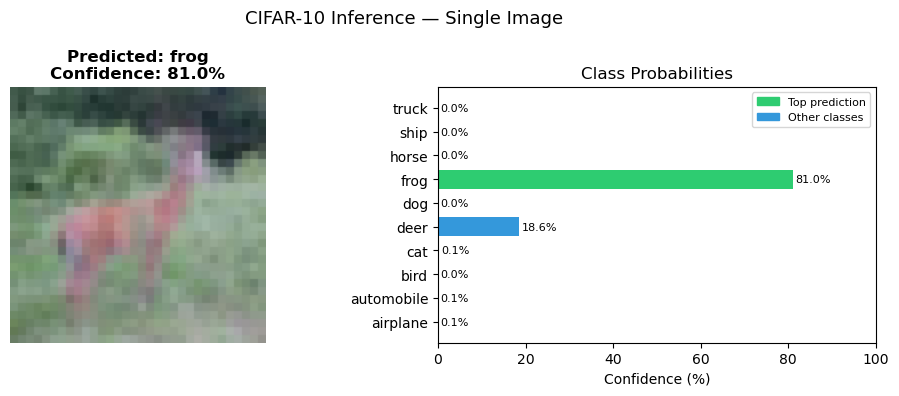


[WRONG]  True: deer  |  Predicted: frog  |  Confidence: 81.0%


In [32]:
# TEST A: Single image from the CIFAR-10 test set ─────────────────
IMAGE_INDEX = 4443   # change this (0–9999) to test different images

img_pil, true_label = test_raw[IMAGE_INDEX]
true_class = CIFAR10_CLASSES[true_label]
print(f"Ground truth: {true_class}")

pred_class, confidence, probs = predict_single_image_EZA(
    image_input = img_pil,
    model       = model,
    device      = str(device),
    show_plot   = True
)

result_emoji = "CORRECT" if pred_class == true_class else "WRONG"
print(f"\n[{result_emoji}]  True: {true_class}  |  Predicted: {pred_class}  |  Confidence: {confidence:.1f}%")

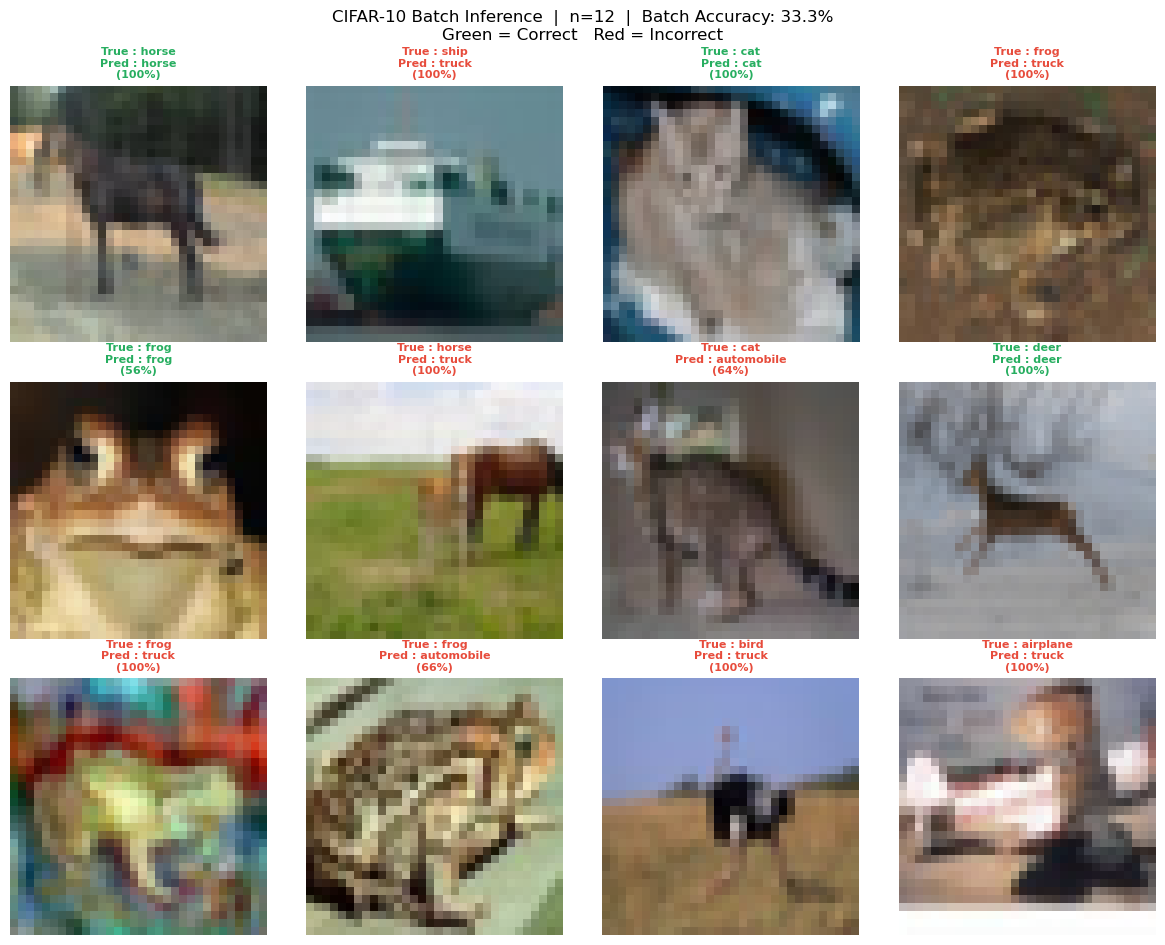


Batch accuracy : 33.3%  (4/12 correct)
 index true_label pred_label  confidence  correct
  9102      horse      horse      100.00     True
  7868       ship      truck      100.00    False
  4176        cat        cat       99.98     True
  4161       frog      truck       99.96    False
  8770       frog       frog       56.16     True
  8919      horse      truck      100.00    False
  3884        cat automobile       63.98    False
  1590       deer       deer       99.54     True
   617       frog      truck       99.69    False
  1562       frog automobile       65.86    False
  1043       bird      truck      100.00    False
  3494   airplane      truck       99.58    False

Overall batch accuracy: 33.3%


In [24]:
# TEST B: Random batch from the test set
results_df = predict_batch_EZA(
    dataset     = test_raw,
    model       = model,
    device      = str(device),
    n           = 12,    # how many images to sample
    random_seed = 50     # change for a different random sample
)

print(results_df.to_string(index=False))
print(f"\nOverall batch accuracy: {results_df['correct'].mean()*100:.1f}%")

Predicted : FROG
Confidence: 74.1%


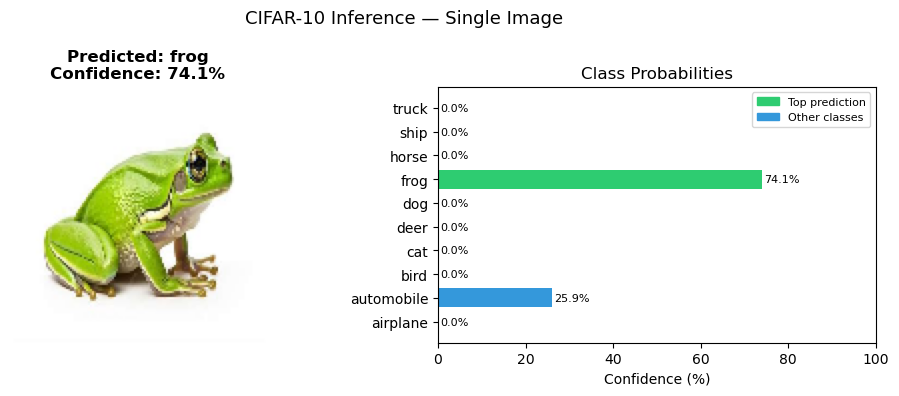

In [25]:
# TEST C: Your own external image file (OPTIONAL) ─────────────────
MY_IMAGE_PATH = "./images_test/frog_test.jpg"   # replace with your image path

if os.path.exists(MY_IMAGE_PATH):
    pred_class, confidence, probs = predict_single_image_EZA(
        image_input = MY_IMAGE_PATH,
        model       = model,
        device      = str(device),
        show_plot   = True
    )
else:
    print(f"File not found: {MY_IMAGE_PATH}")
    print("Update MY_IMAGE_PATH to point to an actual image on disk.")

Predicted : DOG
Confidence: 77.1%


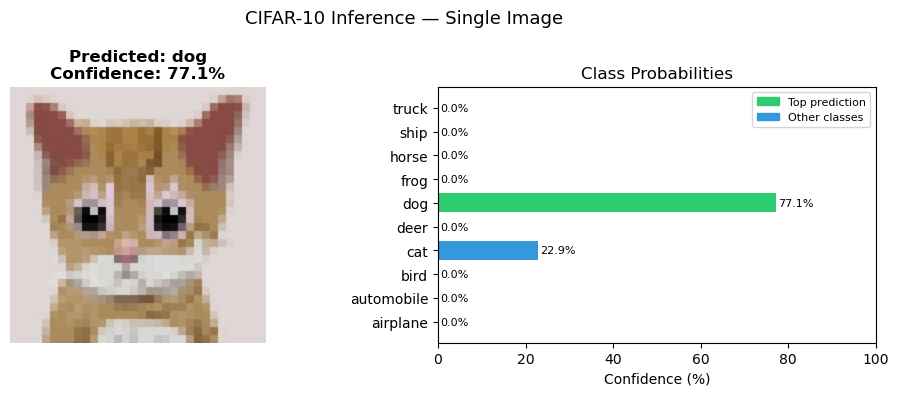

In [26]:
# TEST C: Your own external image file (OPTIONAL) ─────────────────
MY_IMAGE_PATH = "./images_test/cat_test.jpg"   # replace with your image path

if os.path.exists(MY_IMAGE_PATH):
    pred_class, confidence, probs = predict_single_image_EZA(
        image_input = MY_IMAGE_PATH,
        model       = model,
        device      = str(device),
        show_plot   = True
    )
else:
    print(f"File not found: {MY_IMAGE_PATH}")
    print("Update MY_IMAGE_PATH to point to an actual image on disk.")

In [27]:
# TEST D: Full test-set accuracy (all 10,000 images) ──────────────
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, classification_report

test_loader_full = DataLoader(
    torchvision.datasets.CIFAR10(
        root      = './data',
        train     = False,
        download  = False,
        transform = CIFAR10_INFERENCE_TRANSFORM
    ),
    batch_size = 256,
    shuffle    = False,
    num_workers= 2,
    pin_memory = True
)

all_preds  = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader_full:
        images = images.to(device)
        preds  = model(images).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

full_acc = accuracy_score(all_labels, all_preds) * 100
print(f"\nFull test-set accuracy : {full_acc:.2f}%")
print("\nPer-class breakdown:")
print(classification_report(all_labels, all_preds, target_names=CIFAR10_CLASSES))



Full test-set accuracy : 52.51%

Per-class breakdown:
              precision    recall  f1-score   support

    airplane       0.68      0.68      0.68      1000
  automobile       0.43      0.94      0.59      1000
        bird       0.82      0.31      0.45      1000
         cat       0.59      0.33      0.42      1000
        deer       0.88      0.12      0.22      1000
         dog       0.66      0.58      0.62      1000
        frog       0.69      0.42      0.52      1000
       horse       0.69      0.59      0.64      1000
        ship       0.94      0.37      0.53      1000
       truck       0.30      0.90      0.45      1000

    accuracy                           0.53     10000
   macro avg       0.67      0.53      0.51     10000
weighted avg       0.67      0.53      0.51     10000



### Testing the trained Augmented model

In [33]:
# LOAD THE MODEL

model_aug, checkpoint_info = load_model_EZA(
    model           = cifar10_cnn_model_pooled,
    checkpoint_path = "./checkpoints/cnn_aug_final.tar",
    device          = str(device)
)

print(f"\nKeys in checkpoint : {list(checkpoint_info.keys())}")
print(f"Trained for epochs : 0 to {checkpoint_info['epoch']}")

Model loaded from './checkpoints/cnn_aug_final.tar'
  Checkpoint epoch : 24
  Device           : cuda
  Mode             : eval()

Keys in checkpoint : ['epoch', 'model_state_dict', 'optimizer_state_dict', 'results']
Trained for epochs : 0 to 24


Ground truth: deer
Predicted : DEER
Confidence: 100.0%


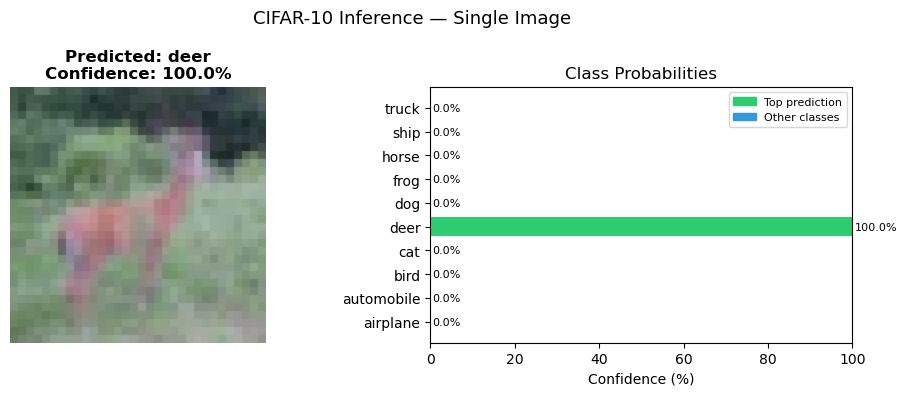


[CORRECT]  True: deer  |  Predicted: deer  |  Confidence: 100.0%


In [34]:
# TEST A: Single image from the CIFAR-10 test set ─────────────────
IMAGE_INDEX = 4443   # change this (0–9999) to test different images

img_pil, true_label = test_raw[IMAGE_INDEX]
true_class = CIFAR10_CLASSES[true_label]
print(f"Ground truth: {true_class}")

pred_class, confidence, probs = predict_single_image_EZA(
    image_input = img_pil,
    model       = model,
    device      = str(device),
    show_plot   = True
)

result_emoji = "CORRECT" if pred_class == true_class else "WRONG"
print(f"\n[{result_emoji}]  True: {true_class}  |  Predicted: {pred_class}  |  Confidence: {confidence:.1f}%")

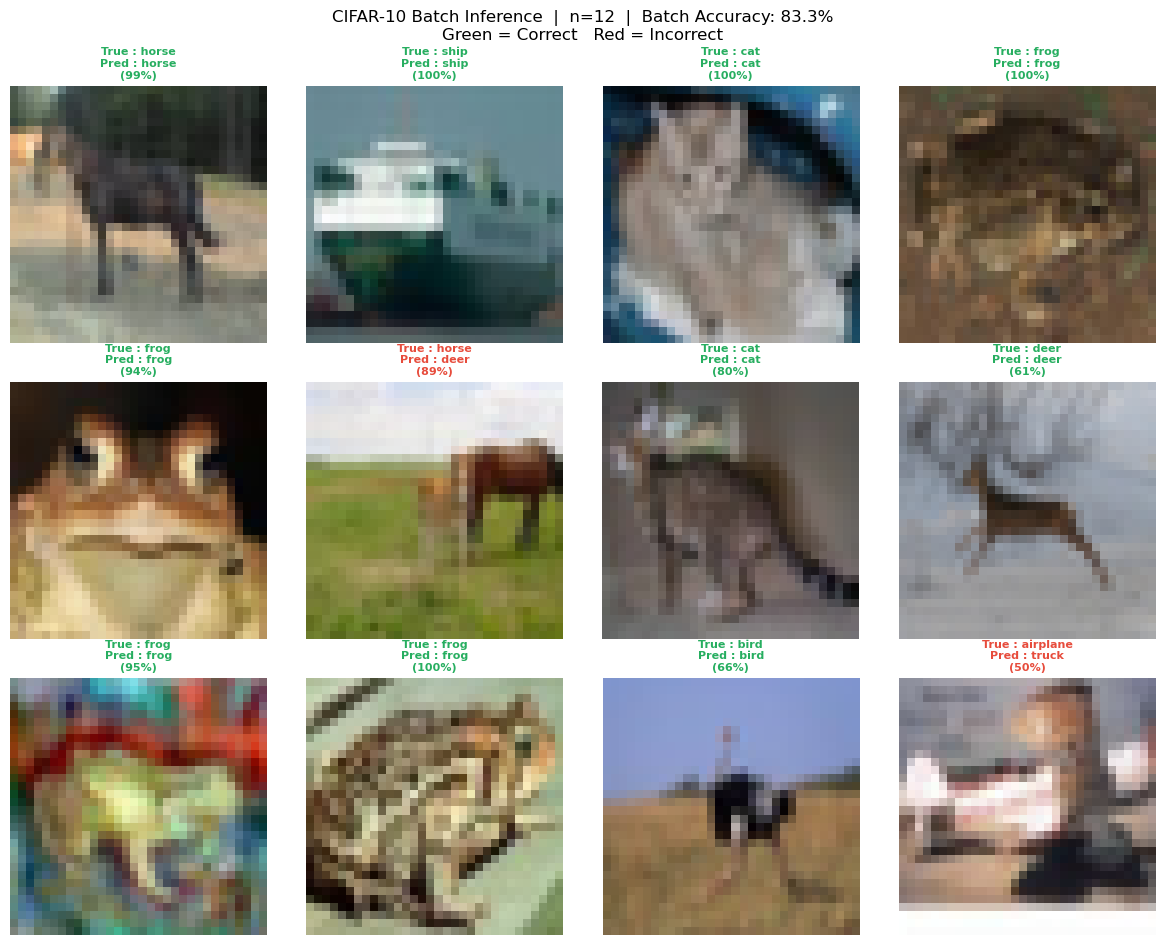


Batch accuracy : 83.3%  (10/12 correct)
 index true_label pred_label  confidence  correct
  9102      horse      horse       98.62     True
  7868       ship       ship       99.99     True
  4176        cat        cat       99.98     True
  4161       frog       frog      100.00     True
  8770       frog       frog       93.98     True
  8919      horse       deer       89.40    False
  3884        cat        cat       80.34     True
  1590       deer       deer       60.75     True
   617       frog       frog       94.96     True
  1562       frog       frog      100.00     True
  1043       bird       bird       65.95     True
  3494   airplane      truck       49.84    False

Overall batch accuracy: 83.3%


In [35]:
# TEST B: Random batch from the test set
results_df = predict_batch_EZA(
    dataset     = test_raw,
    model       = model,
    device      = str(device),
    n           = 12,    # how many images to sample
    random_seed = 50     # change for a different random sample
)

print(results_df.to_string(index=False))
print(f"\nOverall batch accuracy: {results_df['correct'].mean()*100:.1f}%")

Predicted : FROG
Confidence: 100.0%


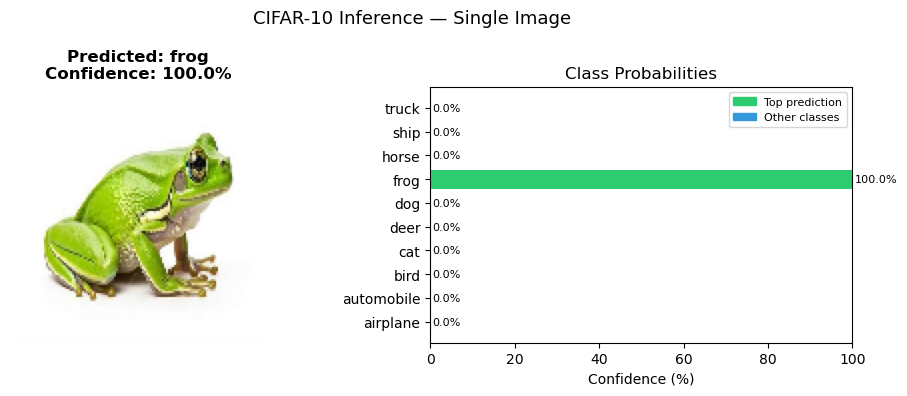

In [36]:
# TEST C: Your own external image file (OPTIONAL) ─────────────────
MY_IMAGE_PATH = "./images_test/frog_test.jpg"   # replace with your image path

if os.path.exists(MY_IMAGE_PATH):
    pred_class, confidence, probs = predict_single_image_EZA(
        image_input = MY_IMAGE_PATH,
        model       = model,
        device      = str(device),
        show_plot   = True
    )
else:
    print(f"File not found: {MY_IMAGE_PATH}")
    print("Update MY_IMAGE_PATH to point to an actual image on disk.")

Predicted : DOG
Confidence: 54.1%


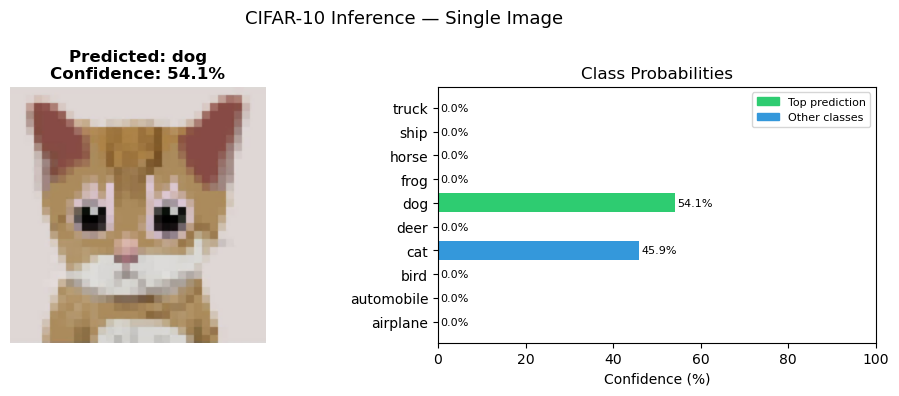

In [37]:
# TEST C: Your own external image file (OPTIONAL) ─────────────────
MY_IMAGE_PATH = "./images_test/cat_test.jpg"   # replace with your image path

if os.path.exists(MY_IMAGE_PATH):
    pred_class, confidence, probs = predict_single_image_EZA(
        image_input = MY_IMAGE_PATH,
        model       = model,
        device      = str(device),
        show_plot   = True
    )
else:
    print(f"File not found: {MY_IMAGE_PATH}")
    print("Update MY_IMAGE_PATH to point to an actual image on disk.")

In [38]:
# TEST D: Full test-set accuracy (all 10,000 images) ──────────────
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, classification_report

test_loader_full = DataLoader(
    torchvision.datasets.CIFAR10(
        root      = './data',
        train     = False,
        download  = False,
        transform = CIFAR10_INFERENCE_TRANSFORM
    ),
    batch_size = 256,
    shuffle    = False,
    num_workers= 2,
    pin_memory = True
)

all_preds  = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader_full:
        images = images.to(device)
        preds  = model(images).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

full_acc = accuracy_score(all_labels, all_preds) * 100
print(f"\nFull test-set accuracy : {full_acc:.2f}%")
print("\nPer-class breakdown:")
print(classification_report(all_labels, all_preds, target_names=CIFAR10_CLASSES))


Full test-set accuracy : 86.42%

Per-class breakdown:
              precision    recall  f1-score   support

    airplane       0.89      0.86      0.87      1000
  automobile       0.95      0.94      0.94      1000
        bird       0.82      0.80      0.81      1000
         cat       0.72      0.79      0.75      1000
        deer       0.78      0.90      0.83      1000
         dog       0.86      0.73      0.79      1000
        frog       0.91      0.89      0.90      1000
       horse       0.92      0.89      0.90      1000
        ship       0.90      0.94      0.92      1000
       truck       0.93      0.91      0.92      1000

    accuracy                           0.86     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.86      0.86     10000

